# 3 · Re-check and improvements
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/twillixa/california-housing-ml/blob/main/notebooks/03_audit_and_improvements.ipynb)

Four questions the report leaves open:
1. Were SVR and the neural network configured fairly?
2. Is gradient boosting really better than the random forest, or is that one lucky split?
3. Does the cleaning leak test information?
4. The maps show location drives price. What happens if the models get the coordinates?

In [1]:
import sys, os
if "google.colab" in sys.modules:  # running on Colab: fetch the repo first
    !git clone -q https://github.com/twillixa/california-housing-ml
    %cd california-housing-ml/notebooks
sys.path.insert(0, os.path.abspath("../src"))

import warnings
os.environ["PYTHONWARNINGS"] = "ignore"  # parallel CV workers don't inherit warnings filters
warnings.filterwarnings("ignore", message=".*encountered in matmul")  # spurious on macOS Accelerate
warnings.filterwarnings("ignore", category=UserWarning)
import pandas as pd
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
from housing import plots
plots.use_style()
pd.set_option("display.precision", 4)
pd.set_option("display.width", 160)
import numpy as np
from housing.data import split, clean, NUM_FEATURES, CAT_FEATURES, COORDS
from housing import models as m
s = split()
df = clean()
X, y = df[NUM_FEATURES + CAT_FEATURES], df["median_house_value"]

## 1 · SVR and the MLP
Both were fit on raw prices (≈ $200,000). For an RBF-kernel SVR the binding limit is `C`. Each support vector's
weight is capped at `C = 100`, tiny next to a target that spans hundreds of thousands of dollars, so the fit is
heavily over-regularised. That is why the report's search found "non-linear kernels R² < 0.50" and kept a linear kernel.
The ablation below separates target scaling from the other changes:

In [2]:
ablation = m.compare(m.svr_mlp_ablation(), s)[["Model", "R2 Test", "R2 Train"]]
ablation.round(4)

,Model,R2 Test,R2 Train
0,MLP · scaled + retuned (corrected),0.7050,0.7202
1,"SVR · RBF, scaled target (corrected)",0.6961,0.7298
2,MLP · scaled target only,0.6919,0.7643
3,MLP · report (raw $),0.6796,0.6803
4,"MLP · retuned, raw $",0.6627,0.6573
5,"SVR · linear, scaled target",0.6116,0.5973
6,"SVR · report (linear, raw $)",0.5994,0.5853
7,"SVR · RBF, raw $",0.4079,0.3902


- **SVR:** the RBF kernel only works on a standardised target (0.41 → 0.70). On the linear kernel, scaling adds only
  ≈ 0.01. So the report's real loss was being steered away from the non-linear kernel.
- **MLP:** scaling the target alone adds ≈ 0.012 (0.680 → 0.692). A smaller learning rate with early stopping adds the
  rest (→ 0.705). Retuning without scaling makes it *worse*, so the two changes work together.

In [3]:
report = m.compare(m.report_models(), s).set_index("Model")
corrected = m.compare(m.corrected_models(), s).set_index("Model")
pd.DataFrame({"report Table 2": pd.Series(m.REPORT_TEST_R2), "rerun (report config)": report["R2 Test"],
              "corrected": corrected["R2 Test"], "corrected train-test gap": corrected["Gap"]}
             ).sort_values("corrected", ascending=False).round(4)

,report Table 2,rerun (report config),corrected,corrected train-test gap
Gradient Boosting,0.7071,0.7074,0.7074,0.0642
Random Forest,0.7063,0.7063,0.7063,0.2278
Neural Network (MLP),0.6796,0.6796,0.7050,0.0152
SVR,0.5994,0.5994,0.6961,0.0337
Linear Regression (OLS),0.6180,0.6180,0.6180,-0.0070
Ridge,0.6180,0.6180,0.6180,-0.0070
Lasso,0.6179,0.6179,0.6179,-0.0069


## 2 · One split or five?
The report ranks models on a single 80/20 split. Five-fold cross-validation (shuffled; the CSV is ordered geographically) shows how much the ranking can move:

,R2 mean,R2 sd,RMSE mean,report_table2_R2
Random Forest,0.7022,0.0057,52954.8309,0.7063
Gradient Boosting,0.7009,0.0069,53067.9939,0.7071
Neural Network (MLP),0.6981,0.0103,53311.7913,0.6796
SVR,0.6917,0.0079,53879.1385,0.5994
Lasso,0.6098,0.0168,60601.0735,0.6179
Ridge,0.6098,0.0166,60605.5938,0.6180
Linear Regression (OLS),0.6096,0.0164,60617.4663,0.6180


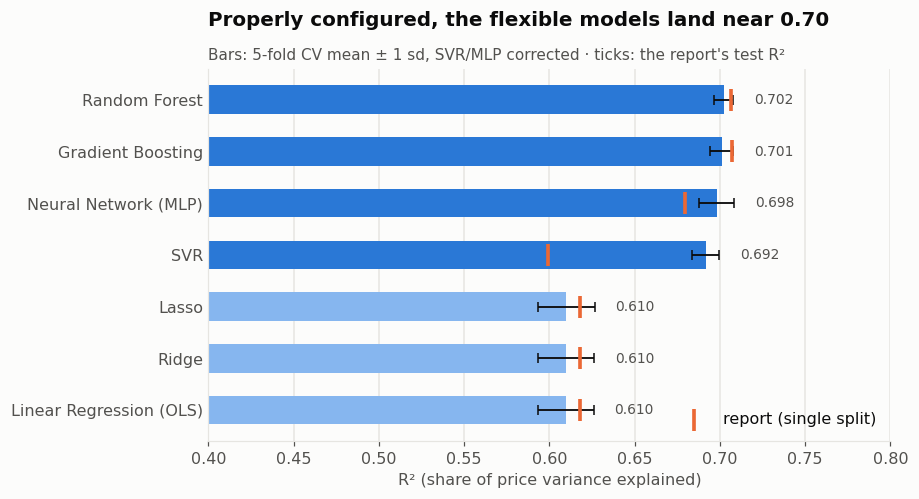

In [4]:
cv = {name: m.cross_validated(model, X, y) for name, model in m.corrected_models().items()}
table = pd.DataFrame({name: {"R2 mean": r["R2 mean"], "R2 sd": r["R2 sd"], "RMSE mean": r["RMSE mean"]}
                      for name, r in cv.items()}).T.astype(float)
out = table.assign(report_table2_R2=pd.Series(m.REPORT_TEST_R2)).sort_values("R2 mean", ascending=False)
out.round(4).to_csv("../reports/model_comparison.csv")
fig = plots.model_comparison(table, pd.Series(m.REPORT_TEST_R2)); plots.save(fig, "model_comparison")
out.round(4)

Models share the same folds, so the right comparison is **paired**: the per-fold difference, not each model's own spread.

In [5]:
pairs = [("Random Forest", "Gradient Boosting"), ("Random Forest", "Neural Network (MLP)"),
         ("Gradient Boosting", "Neural Network (MLP)"), ("Random Forest", "SVR"), ("Gradient Boosting", "SVR")]
pd.DataFrame({f"{a} − {b}": m.paired_difference(cv[a], cv[b]) for a, b in pairs}).T.round(4)

,mean diff,t,folds better,folds
Random Forest − Gradient Boosting,0.0013,1.9017,4.0,5.0
Random Forest − Neural Network (MLP),0.0041,1.6742,4.0,5.0
Gradient Boosting − Neural Network (MLP),0.0028,1.1321,4.0,5.0
Random Forest − SVR,0.0105,7.3580,5.0,5.0
Gradient Boosting − SVR,0.0092,6.0820,5.0,5.0


- **Random forest, gradient boosting and the MLP are tied.** Their paired differences are ≤ 0.004 R² with t < 2, so the data
  does not support choosing gradient boosting over the random forest.
- **SVR is about 0.01 behind**, and that gap is real: it loses in all five folds (t ≈ 6–7).
- The linear models trail by about 0.09.

The report also preferred gradient boosting for its smaller train-test gap (0.06 vs 0.23). A gap measures how much a
model memorises. Generalisation is the test score itself, and that is the same for both.

*Note:* these CV runs use the report's cleaning, whose imputation median and caps see every row. Section 3 shows
that this leak doesn't matter here.

## 3 · Cleaning fitted on the training rows only
The median imputation and the 99th-percentile caps used all rows, test rows included:

In [6]:
leak_free = split(leak_free=True)
gb = m.report_models()["Gradient Boosting"]
r = m.evaluate("GB", gb, leak_free.X_train, leak_free.y_train, leak_free.X_test, leak_free.y_test)
print(f"Gradient boosting test R²: {report.loc['Gradient Boosting', 'R2 Test']:.4f} (rerun, all-row cleaning) "
      f"vs {r['R2 Test']:.4f} (leak-free)")

Gradient boosting test R²: 0.7074 (rerun, all-row cleaning) vs 0.7071 (leak-free)


A technically valid point, but practically irrelevant here.

## 4 · Giving the models the coordinates
Three ways to score it:
- **random CV**: test blocks are scattered among training blocks, so their neighbours are in the training set.
- **spatial CV, 1° cells**: whole 1° × 1° grid cells (≈ 110 km) are held out.
- **spatial CV, 2° cells**: larger regions are held out, so far fewer test blocks have a neighbour just across a cell border.

Per-fold gain from adding coordinates:


,Random 5-fold CV,"Spatial CV, 1° cells","Spatial CV, 2° cells"
fold 1,0.095,0.041,0.059
fold 2,0.105,0.105,-0.102
fold 3,0.094,0.161,0.025
fold 4,0.101,0.030,0.020
fold 5,0.103,-0.008,0.025


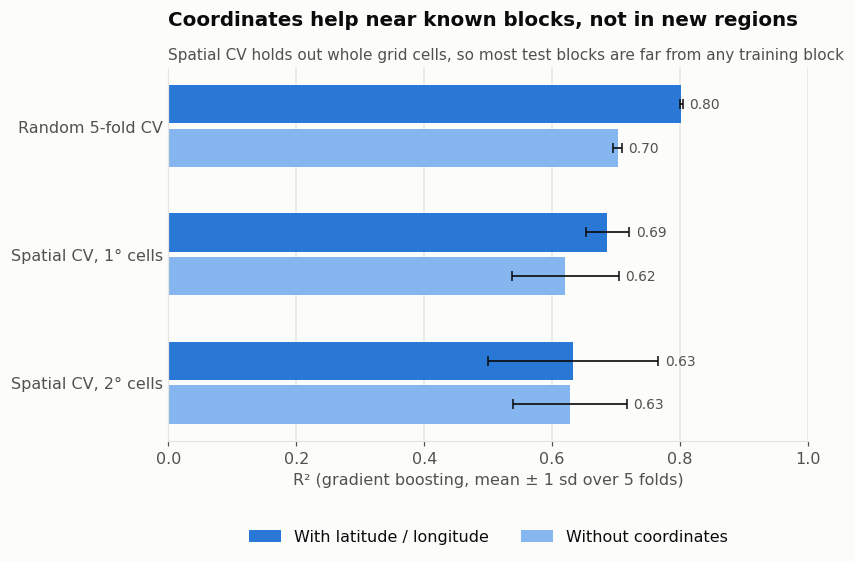

In [7]:
features_geo = NUM_FEATURES + COORDS
X_geo = df[features_geo + CAT_FEATURES]
designs = {"random": "Random 5-fold CV", "spatial1": "Spatial CV, 1° cells", "spatial2": "Spatial CV, 2° cells"}
runs, rows = {}, {}
for label, Xs, feats in [("Without coordinates", X, NUM_FEATURES), ("With latitude / longitude", X_geo, features_geo)]:
    runs[label] = {
        "random": m.cross_validated(m.final_gradient_boosting(feats), Xs, y),
        "spatial1": m.cross_validated(m.final_gradient_boosting(feats), Xs, y, cv="spatial", groups=m.spatial_cells(df, 1.0)),
        "spatial2": m.cross_validated(m.final_gradient_boosting(feats), Xs, y, cv="spatial", groups=m.spatial_cells(df, 2.0)),
    }
    rows[label] = {k: v for d, r in runs[label].items() for k, v in ((d, r["R2 mean"]), (f"{d}_sd", r["R2 sd"]))}
location = pd.DataFrame(rows).T
location.round(4).to_csv("../reports/location_gain.csv")
fig = plots.location_gain(location, designs); plots.save(fig, "location_gain")
gains = pd.DataFrame({designs[d]: runs["With latitude / longitude"][d]["fold R2"] - runs["Without coordinates"][d]["fold R2"]
                      for d in designs}, index=[f"fold {i + 1}" for i in range(5)])
print("Per-fold gain from adding coordinates:")
gains.round(3)

In [8]:
s_geo = split(features=features_geo + CAT_FEATURES)
geo_model = m.final_gradient_boosting(features_geo)
geo = m.evaluate("GB + coordinates", geo_model, s_geo.X_train, s_geo.y_train, s_geo.X_test, s_geo.y_test)
print(f"Test R² {geo['R2 Test']:.4f} · RMSE ${geo['RMSE Test']:,.0f} · MAE ${geo['MAE Test']:,.0f}")
pred = s_geo.test[["longitude", "latitude", "ocean_proximity", "median_income", "median_house_value"]].copy()
pred["predicted_value"] = geo_model.predict(s_geo.X_test).round(0)
pred["error"] = pred["predicted_value"] - pred["median_house_value"]
pred.to_csv("../reports/test_predictions.csv", index=False)
pred.head()

Test R² 0.8053 · RMSE $42,675 · MAE $28,963


,longitude,latitude,ocean_proximity,median_income,median_house_value,predicted_value,error
15350,-122.48,37.72,NEAR OCEAN,3.2321,112500,316849.0,204349.0
1147,-121.53,39.52,INLAND,2.4821,73800,81148.0,7348.0
3682,-118.41,34.20,<1H OCEAN,3.5164,217200,182290.0,-34910.0
5449,-118.24,34.23,<1H OCEAN,6.0100,254200,310823.0,56623.0
16555,-120.48,34.70,NEAR OCEAN,4.3162,136400,213892.0,77492.0


With coordinates, the same gradient boosting model explains about 80% of price variance instead of 70% on blocks
*mixed in with* its training data. Its RMSE falls by about $9,600 (from $52,300 to $42,700). That is the realistic
setting for filling gaps in a known market.

The gain does **not** transfer reliably to new regions. Holding out 1° cells it averages +0.07, but varies from −0.01
to +0.16 across folds. Holding out 2° regions it is essentially zero. Most of what latitude and longitude add is
"nearby blocks cost about the same", i.e. interpolation, not a portable rule about California.

## Audit log

| Issue in the original | Effect | Fix |
|---|---|---|
| SVR and MLP fit on raw dollar prices | RBF-SVR R² 0.41, so a linear kernel was kept (0.60); MLP 0.68 | standardised target (+ RBF for SVR, smaller learning rate + early stopping for the MLP): SVR 0.70, MLP 0.705 |
| Model choice on one 80/20 split | GB "beats" RF by ΔR² 0.0008 | 5-fold paired CV: RF, GB and MLP tie; SVR ≈ 0.01 behind |
| Coordinates excluded from the models | location only via a 4-level category | + lat/lon: R² 0.70 → 0.80 near known blocks; little or no gain in unseen regions |
| Cleaning statistics fitted on all rows | minor train/test leakage | `split(leak_free=True)`: no measurable change |
| Ratio outliers (group-quarters blocks) not handled before KMeans | "cluster 3" is 3 blocks averaging 782 people per household | clip ratios: notebook 4 |
| Report text vs code | "six models" (seven listed), "stratified split" (random), SVR ε 0.1 (code: 0.5); Fig. 16 SVR bars ≈ 0.40 ≠ Table 2 | documented; code values used |